# Porosity Data Visualization

This notebook loads and visualizes the data from `porosity.mat`.

In [1]:
# Import necessary libraries
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd

In [2]:
# Load the .mat file
mat_data = sio.loadmat('porosity.mat')

# Display available variables in the .mat file
print("Variables in the .mat file:")
for key in mat_data.keys():
    if not key.startswith('__'):  # Skip metadata
        print(f"- {key}: {type(mat_data[key])}, Shape: {mat_data[key].shape if hasattr(mat_data[key], 'shape') else 'N/A'}")

Variables in the .mat file:
- porosity: <class 'numpy.ndarray'>, Shape: (3, 25)


In [3]:
# Basic exploration of the main data arrays
for key in mat_data.keys():
    if not key.startswith('__'):
        data = mat_data[key]
        if hasattr(data, 'shape') and len(data.shape) > 0:
            print(f"\n{key} - Statistics:")
            if np.issubdtype(data.dtype, np.number):
                print(f"  Min: {np.min(data)}")
                print(f"  Max: {np.max(data)}")
                print(f"  Mean: {np.mean(data)}")
                print(f"  Std Dev: {np.std(data)}")


porosity - Statistics:


TypeError: Image data of dtype object cannot be converted to float

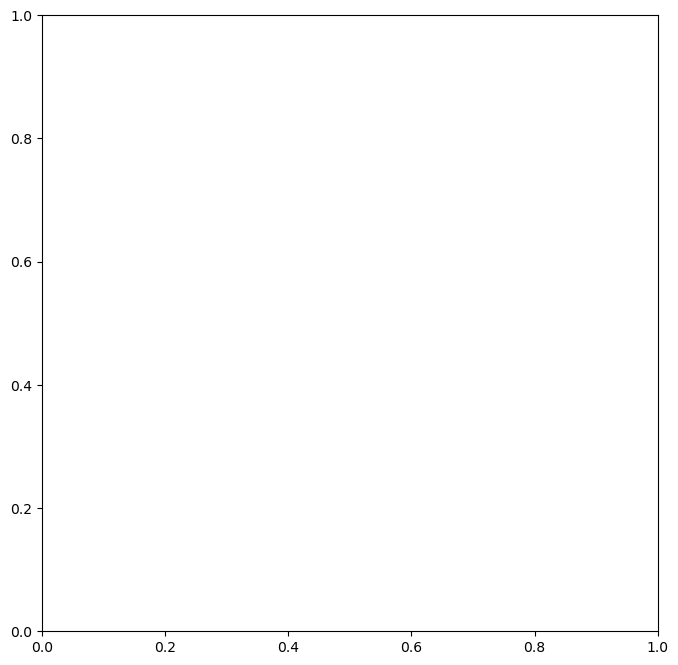

In [4]:
# Visualize 2D data if available
for key in mat_data.keys():
    if not key.startswith('__'):
        data = mat_data[key]
        if hasattr(data, 'shape') and len(data.shape) == 2:
            plt.figure(figsize=(10, 8))
            plt.imshow(data, cmap='viridis')
            plt.colorbar(label='Value')
            plt.title(f'{key} Visualization')
            plt.xlabel('X')
            plt.ylabel('Y')
            plt.show()

In [ ]:
# Visualize 1D data if available
for key in mat_data.keys():
    if not key.startswith('__'):
        data = mat_data[key]
        if hasattr(data, 'shape') and len(data.shape) == 1 or (len(data.shape) == 2 and min(data.shape) == 1):
            # Flatten if it's a 2D array with one dimension of size 1
            if len(data.shape) == 2:
                data = data.flatten()
                
            plt.figure(figsize=(12, 6))
            plt.plot(data)
            plt.title(f'{key} Plot')
            plt.xlabel('Index')
            plt.ylabel('Value')
            plt.grid(True)
            plt.show()

In [ ]:
# Advanced visualization if there's 3D data
for key in mat_data.keys():
    if not key.startswith('__'):
        data = mat_data[key]
        if hasattr(data, 'shape') and len(data.shape) == 3:
            # Display slices of the 3D volume
            z_mid = data.shape[2] // 2
            y_mid = data.shape[1] // 2
            x_mid = data.shape[0] // 2
            
            fig, axes = plt.subplots(1, 3, figsize=(18, 6))
            
            # XY plane (Z fixed)
            im1 = axes[0].imshow(data[:, :, z_mid], cmap='viridis')
            axes[0].set_title(f'{key} - XY Plane (Z={z_mid})')
            plt.colorbar(im1, ax=axes[0])
            
            # XZ plane (Y fixed)
            im2 = axes[1].imshow(data[:, y_mid, :], cmap='viridis')
            axes[1].set_title(f'{key} - XZ Plane (Y={y_mid})')
            plt.colorbar(im2, ax=axes[1])
            
            # YZ plane (X fixed)
            im3 = axes[2].imshow(data[x_mid, :, :], cmap='viridis')
            axes[2].set_title(f'{key} - YZ Plane (X={x_mid})')
            plt.colorbar(im3, ax=axes[2])
            
            plt.tight_layout()
            plt.show()

## Custom Visualizations

Based on the specific structure of the porosity data, additional custom visualizations can be added below.